In this notebook we simulate future stock prices, risk-free rates, 3 year bonds and sharpe ratios from 31 october 2014 to 31 october 2033. We assume that the voatility follows stockastic process (Heston Model). We assume that other 

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import market_stochastic_simulation as mss
import retirement_client as pensioner

# 1. Market Simulation Code

$
\begin{cases}
r_{t+dt} = r_t + \kappa_r (\bar{lt_r} - r_t) dt + \sigma_r \sqrt{dt} Z_t^r\\
SR_{t+dt} = SR_t + \kappa_sr (\bar{lt_sr} - SR_t) dt + \sigma_SR \sqrt{dt} Z_t^SR\\
V_{t+dt} = V_t + \kappa_v (lt_V - V_t) dt + \sigma_V \sqrt{V_t} \sqrt{dt} Z_t^V\\
S_{t+dt} = S_t \times \exp \left( \left( r + \bar{\lambda_0} \sigma_t - \frac{1}{2} \sigma_t^2 \right) dt + \sigma_t \sqrt{dt} Z_t^S \right) \\
\end{cases}
$

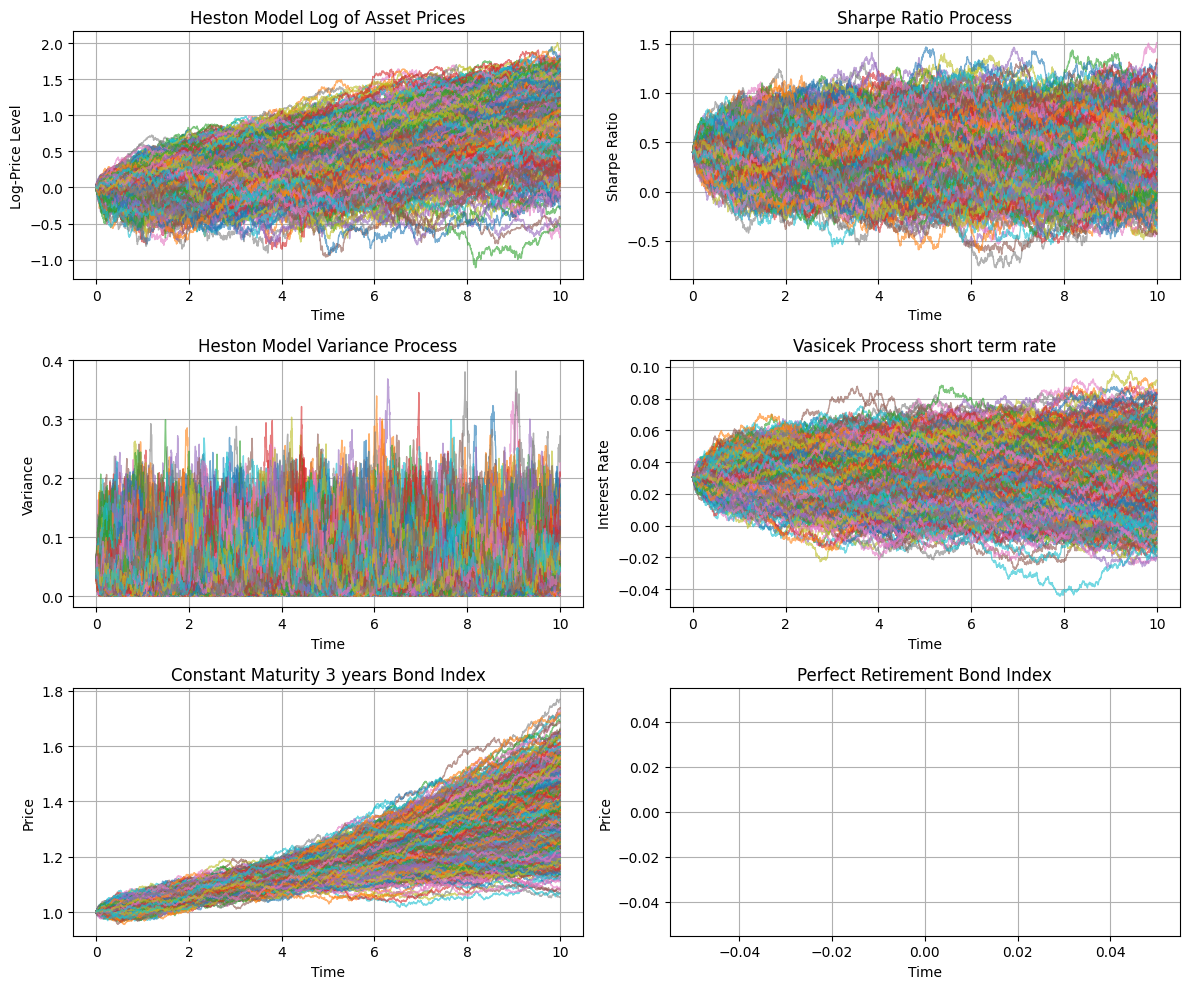

In [2]:
# Parameters
S0 = 1.0              # asset price
T = 10                  # time in years
N = 252*T              # number of time steps in simulation
M = 1000                # number of simulated paths
seed = 123              # simulation seed

simulated_market = mss.MarketSimulator(T,N,M,seed, S0)
simulated_market.plot_market_simulation()

## Initialize client

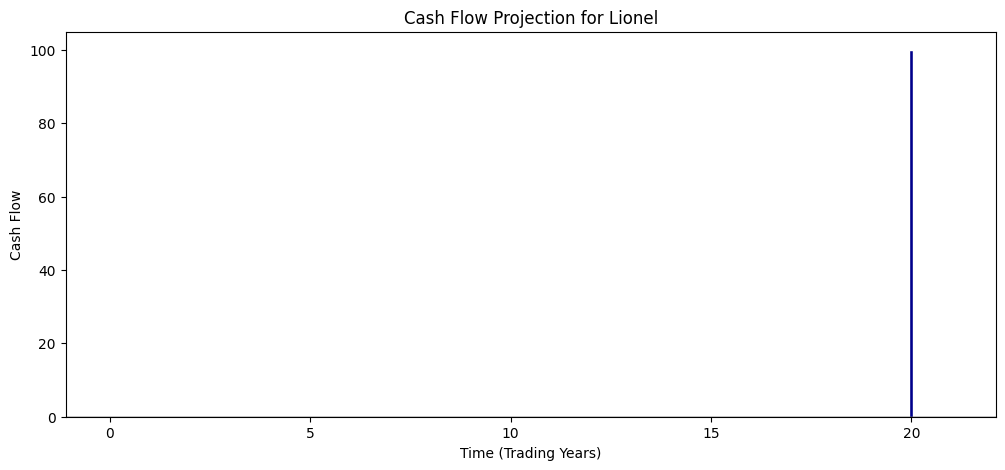

In [4]:
client = pensioner.RetirementClient("Lionel",
                           accumulation_years=10,
                           accumulation_cash_flow=0,
                           decumulation_years=1,
                           decumulation_cash_flow=50000,
                           periodicity = 12)

client.plot_cash_flows()

Now we know cash flows that the client needs. Hence, we can simulate perfect retirement bond for him

In [5]:
simulated_market.calculate_perfect_retirement_bond(client)

Simulating scenarios: 100%|█████████████████| 1000/1000 [01:42<00:00,  9.72it/s]
/Users/aleksandrmikhailov/Desktop/GitHub_EDHEC/Retirement solution/Goal-Based-Investing/market_stochastic_simulation.py:295: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  retirement_bond_p.loc[:, simulation_number] = result[i]


Plot the market and the retirement bond index. If you would use M = 31, you would get full retirement bond price with ladder

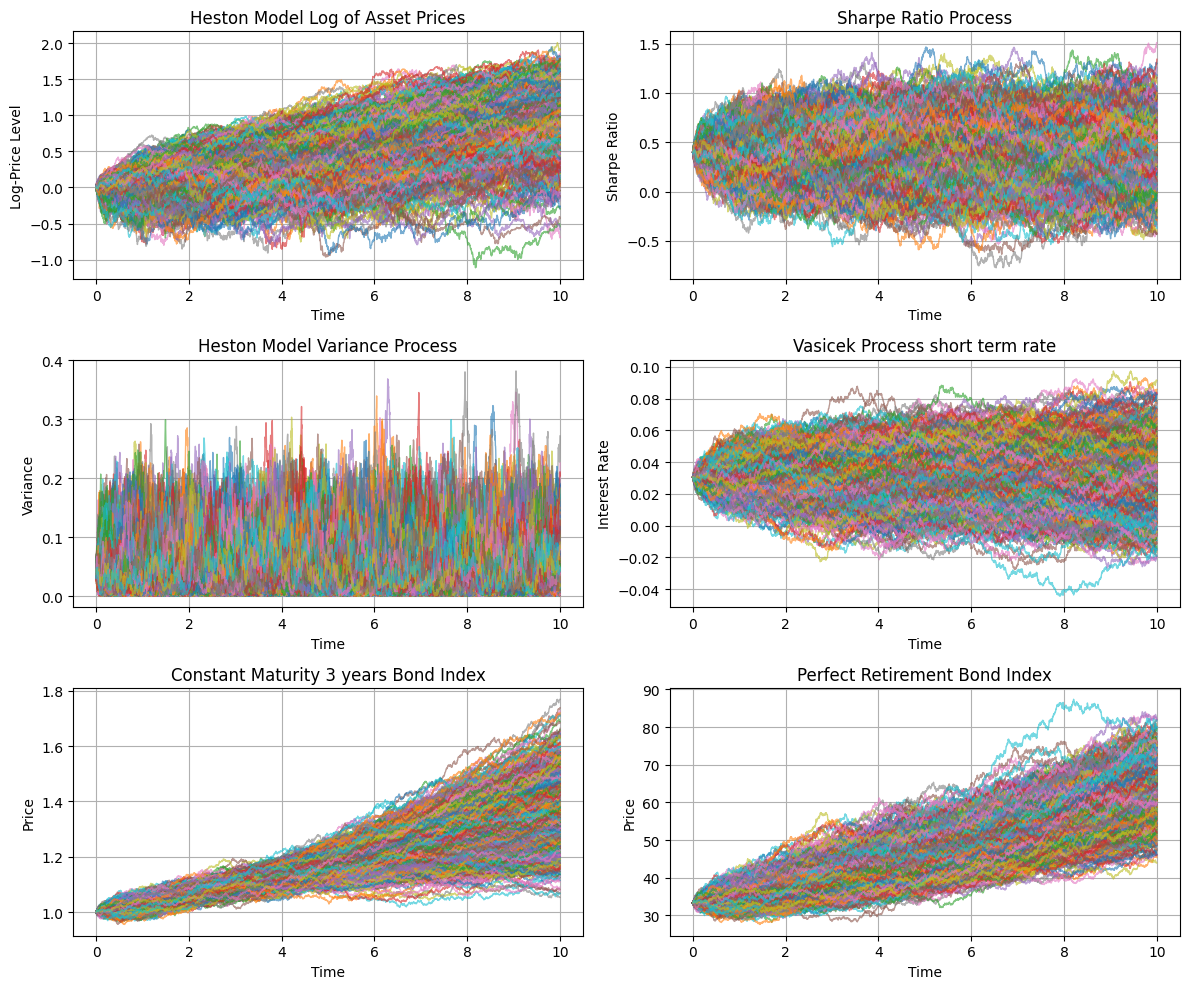

In [6]:
simulated_market.plot_market_simulation()

## Set up a fund